## Reinforcement Learning: The Vacuum World Problem

Here, we attempt to solve the Vacuum World Problem using three important Reinforcement Learning methods:


- Adaptive Dynamic Programming (ADP): A model-based method that learns a model of the environment and uses it to make decisions.

- Action-utility learning: Shown with Q-learning, which learns the value of actions in different states without needing a model of the environment.

- Policy search: A method that directly searches over policies, then evaluates them based on their performance in the environment.

### Problem Description

There are two rooms, A and B. The agent is in one room. Each room can be dirty or clean.

```text
State = (agent_position, dirt_in_A, dirt_in_B)
```

Actions:

- Left: move toward room A.
- Right: move toward room B.
- Suck: clean the current room if it is dirty.
- NoOp: do nothing.

Rewards:

- Suck on a dirty square: +10.
- Any non-terminal step has a small cost: -1.
- Bumping into the same side or sucking a clean square is allowed but not useful.
- When both rooms are clean, the state is terminal.

In [1]:
from collections import Counter, defaultdict
from itertools import product
import random
import statistics

POSITIONS = ("A", "B")
ACTIONS = ("Left", "Right", "Suck", "NoOp")
GAMMA = 0.90
SLIP_PROBABILITY = 0.10
MAX_STEPS = 20

STATES = tuple((position, dirt_a, dirt_b) for position in POSITIONS for dirt_a in (0, 1) for dirt_b in (0, 1))
NONTERMINAL_STATES = tuple(state for state in STATES if not (state[1] == 0 and state[2] == 0))


def is_terminal(state):
    _, dirt_a, dirt_b = state
    return dirt_a == 0 and dirt_b == 0


def reset_state(rng, both_dirty=False):
    position = rng.choice(POSITIONS)
    if both_dirty:
        return (position, 1, 1)
    dirt_a, dirt_b = rng.choice([(1, 1), (1, 0), (0, 1)])
    return (position, dirt_a, dirt_b)


def vacuum_step(state, action, rng):
    position, dirt_a, dirt_b = state
    if is_terminal(state):
        return state, 0.0

    reward = -1.0

    if action == "Suck":
        if position == "A" and dirt_a:
            dirt_a = 0
            reward = 10.0
        elif position == "B" and dirt_b:
            dirt_b = 0
            reward = 10.0
        else:
            reward = -2.0
    elif action == "Left":
        if rng.random() >= SLIP_PROBABILITY:
            position = "A"
    elif action == "Right":
        if rng.random() >= SLIP_PROBABILITY:
            position = "B"
    elif action == "NoOp":
        reward = -1.0
    else:
        raise ValueError(f"Unknown action: {action}")

    return (position, dirt_a, dirt_b), reward


def state_label(state):
    position, dirt_a, dirt_b = state
    return f"pos={position}, A={'dirty' if dirt_a else 'clean'}, B={'dirty' if dirt_b else 'clean'}"


def print_policy(policy, title="Policy"):
    print(title)
    for state in NONTERMINAL_STATES:
        print(f"  {state_label(state):40s} -> {policy.get(state, '?')}")

print("Number of states:", len(STATES))
print("Number of non-terminal states:", len(NONTERMINAL_STATES))
print("Actions:", ACTIONS)
print("Example state:", state_label(("A", 1, 0)))

Number of states: 8
Number of non-terminal states: 6
Actions: ('Left', 'Right', 'Suck', 'NoOp')
Example state: pos=A, A=dirty, B=clean


All three methods will be evaluated using the same simulator and the same discounted return formula.

In [2]:
def run_episode(policy, start_state=("A", 1, 1), seed=0, max_steps=MAX_STEPS, return_trace=False):
    rng = random.Random(seed)
    state = start_state
    trace = []
    total = 0.0
    discount = 1.0

    for step_index in range(max_steps):
        if is_terminal(state):
            break
        action = policy(state)
        next_state, reward = vacuum_step(state, action, rng)
        trace.append((state, action, reward, next_state))
        total += discount * reward
        discount *= GAMMA
        state = next_state

    if return_trace:
        return total, trace
    return total


def evaluate_policy(policy, episodes=100, seed=123, both_dirty=True):
    rng = random.Random(seed)
    returns = []
    for episode in range(episodes):
        start = reset_state(rng, both_dirty=both_dirty)
        returns.append(run_episode(policy, start_state=start, seed=seed + episode))
    return statistics.mean(returns)


def greedy_reference_policy(state):
    position, dirt_a, dirt_b = state
    if position == "A" and dirt_a:
        return "Suck"
    if position == "B" and dirt_b:
        return "Suck"
    if dirt_a:
        return "Left"
    if dirt_b:
        return "Right"
    return "NoOp"

print_policy({state: greedy_reference_policy(state) for state in NONTERMINAL_STATES}, "Human-designed reference policy")
print("Mean return from random dirty starts:", round(evaluate_policy(greedy_reference_policy), 3))

Human-designed reference policy
  pos=A, A=clean, B=dirty                  -> Right
  pos=A, A=dirty, B=clean                  -> Suck
  pos=A, A=dirty, B=dirty                  -> Suck
  pos=B, A=clean, B=dirty                  -> Suck
  pos=B, A=dirty, B=clean                  -> Left
  pos=B, A=dirty, B=dirty                  -> Suck
Mean return from random dirty starts: 16.926


### Adaptive Dynamic Programming (ADP)

ADP is model-based. The agent learns:

- A transition model `P(s' | s, a)` from observed transition counts;
- A reward model `R(s, a, s')` from observed rewards;
- A value function by solving the learned MDP with value iteration.

This mirrors the lecture idea: learn the model first, then use Bellman backups to plan.

In [3]:
def choose_epsilon_greedy_from_policy(state, policy, epsilon, rng):
    if rng.random() < epsilon or state not in policy:
        return rng.choice(ACTIONS)
    return policy[state]


def build_model(transition_counts, reward_sums):
    transition_model = {}
    reward_model = {}

    for state_action, next_counter in transition_counts.items():
        total = sum(next_counter.values())
        transition_model[state_action] = {next_state: count / total for next_state, count in next_counter.items()}
        for next_state, count in next_counter.items():
            reward_model[(state_action[0], state_action[1], next_state)] = reward_sums[(state_action[0], state_action[1], next_state)] / count

    return transition_model, reward_model


def model_q_value(state, action, values, transition_model, reward_model, gamma=GAMMA):
    if (state, action) not in transition_model:
        # Unknown actions are treated as a self-loop with a small cost.
        return -1.0 + gamma * values[state]

    total = 0.0
    for next_state, probability in transition_model[(state, action)].items():
        reward = reward_model[(state, action, next_state)]
        total += probability * (reward + gamma * values[next_state])
    return total


def value_iteration_from_model(transition_model, reward_model, gamma=GAMMA, tolerance=1e-8, max_iterations=500):
    values = {state: 0.0 for state in STATES}

    for iteration in range(max_iterations):
        delta = 0.0
        new_values = values.copy()
        for state in NONTERMINAL_STATES:
            best = max(model_q_value(state, action, values, transition_model, reward_model, gamma) for action in ACTIONS)
            new_values[state] = best
            delta = max(delta, abs(new_values[state] - values[state]))
        values = new_values
        if delta < tolerance:
            break

    policy = {
        state: max(ACTIONS, key=lambda action: model_q_value(state, action, values, transition_model, reward_model, gamma))
        for state in NONTERMINAL_STATES
    }
    return values, policy, iteration + 1


def train_adp(episodes=300, seed=10):
    rng = random.Random(seed)
    transition_counts = defaultdict(Counter)
    reward_sums = defaultdict(float)
    policy = {state: rng.choice(ACTIONS) for state in NONTERMINAL_STATES}
    scores = []

    for episode in range(episodes):
        state = reset_state(rng)
        epsilon = max(0.05, 0.40 * (1 - episode / episodes))

        for _ in range(MAX_STEPS):
            if is_terminal(state):
                break
            action = choose_epsilon_greedy_from_policy(state, policy, epsilon, rng)
            next_state, reward = vacuum_step(state, action, rng)

            transition_counts[(state, action)][next_state] += 1
            reward_sums[(state, action, next_state)] += reward
            state = next_state

        transition_model, reward_model = build_model(transition_counts, reward_sums)
        values, policy, _ = value_iteration_from_model(transition_model, reward_model)

        if episode in {0, 1, 2, 9, 49, 99, episodes - 1}:
            scores.append((episode + 1, evaluate_policy(lambda s, p=policy: p.get(s, "NoOp"), episodes=50, seed=900)))

    transition_model, reward_model = build_model(transition_counts, reward_sums)
    values, policy, sweeps = value_iteration_from_model(transition_model, reward_model)
    return values, policy, transition_model, reward_model, transition_counts, scores, sweeps

adp_values, adp_policy, adp_T, adp_R, adp_counts, adp_scores, adp_sweeps = train_adp()
print("ADP learning curve checkpoints:")
for episode, score in adp_scores:
    print(f"  after {episode:>3} episodes: mean return = {score:+.3f}")
print(f"\nFinal value-iteration sweeps on learned model: {adp_sweeps}")
print_policy(adp_policy, "ADP greedy policy from the learned model")
print("ADP mean return:", round(evaluate_policy(lambda s: adp_policy.get(s, "NoOp")), 3))

ADP learning curve checkpoints:
  after   1 episodes: mean return = -8.784
  after   2 episodes: mean return = +15.621
  after   3 episodes: mean return = +15.621
  after  10 episodes: mean return = +15.621
  after  50 episodes: mean return = +15.621
  after 100 episodes: mean return = +16.973
  after 300 episodes: mean return = +16.973

Final value-iteration sweeps on learned model: 13
ADP greedy policy from the learned model
  pos=A, A=clean, B=dirty                  -> Right
  pos=A, A=dirty, B=clean                  -> Suck
  pos=A, A=dirty, B=dirty                  -> Suck
  pos=B, A=clean, B=dirty                  -> Suck
  pos=B, A=dirty, B=clean                  -> Left
  pos=B, A=dirty, B=dirty                  -> Suck
ADP mean return: 16.926


In [4]:
print("A few learned transition probabilities:")
for key in sorted(adp_T.keys(), key=str)[:8]:
    state, action = key
    outcomes = ", ".join(
        f"{state_label(next_state)} with P={probability:.2f}"
        for next_state, probability in adp_T[key].items()
    )
    print(f"  {state_label(state)} + {action:>5} -> {outcomes}")

A few learned transition probabilities:
  pos=A, A=clean, B=dirty +  Left -> pos=A, A=clean, B=dirty with P=1.00
  pos=A, A=clean, B=dirty +  NoOp -> pos=A, A=clean, B=dirty with P=1.00
  pos=A, A=clean, B=dirty + Right -> pos=B, A=clean, B=dirty with P=0.86, pos=A, A=clean, B=dirty with P=0.14
  pos=A, A=clean, B=dirty +  Suck -> pos=A, A=clean, B=dirty with P=1.00
  pos=A, A=dirty, B=clean +  Left -> pos=A, A=dirty, B=clean with P=1.00
  pos=A, A=dirty, B=clean +  NoOp -> pos=A, A=dirty, B=clean with P=1.00
  pos=A, A=dirty, B=clean + Right -> pos=B, A=dirty, B=clean with P=1.00
  pos=A, A=dirty, B=clean +  Suck -> pos=A, A=clean, B=clean with P=1.00


### Action-Utility Learning with Q-learning

Action-utility learning estimates `Q(s, a)`, the value of taking action a in state s. Q-learning is model-free: it does not learn `P(s' | s, a)`.

The update is:

```text
Q(s, a) <- Q(s, a) + alpha [ r + gamma max_a' Q(s', a') - Q(s, a) ]
```

In [5]:
def q_learning(episodes=1200, seed=20, alpha=0.25):
    rng = random.Random(seed)
    q = defaultdict(float)
    scores = []

    for episode in range(episodes):
        state = reset_state(rng)
        epsilon = max(0.03, 0.50 * (1 - episode / episodes))

        for _ in range(MAX_STEPS):
            if is_terminal(state):
                break
            if rng.random() < epsilon:
                action = rng.choice(ACTIONS)
            else:
                action = max(ACTIONS, key=lambda a: q[(state, a)])

            next_state, reward = vacuum_step(state, action, rng)
            best_next = 0.0 if is_terminal(next_state) else max(q[(next_state, next_action)] for next_action in ACTIONS)
            td_target = reward + GAMMA * best_next
            td_error = td_target - q[(state, action)]
            q[(state, action)] += alpha * td_error
            state = next_state

        if episode in {0, 1, 2, 9, 49, 199, 599, episodes - 1}:
            policy = {s: max(ACTIONS, key=lambda a: q[(s, a)]) for s in NONTERMINAL_STATES}
            scores.append((episode + 1, evaluate_policy(lambda s, p=policy: p.get(s, "NoOp"), episodes=50, seed=700)))

    policy = {state: max(ACTIONS, key=lambda action: q[(state, action)]) for state in NONTERMINAL_STATES}
    return q, policy, scores

q_values, q_policy, q_scores = q_learning()
print("Q-learning checkpoints:")
for episode, score in q_scores:
    print(f"  after {episode:>4} episodes: mean return = {score:+.3f}")
print_policy(q_policy, "Q-learning greedy policy")
print("Q-learning mean return:", round(evaluate_policy(lambda s: q_policy.get(s, "NoOp")), 3))

Q-learning checkpoints:
  after    1 episodes: mean return = -8.784
  after    2 episodes: mean return = +9.582
  after    3 episodes: mean return = +9.582
  after   10 episodes: mean return = +9.582
  after   50 episodes: mean return = +17.009
  after  200 episodes: mean return = +17.009
  after  600 episodes: mean return = +17.009
  after 1200 episodes: mean return = +17.009
Q-learning greedy policy
  pos=A, A=clean, B=dirty                  -> Right
  pos=A, A=dirty, B=clean                  -> Suck
  pos=A, A=dirty, B=dirty                  -> Suck
  pos=B, A=clean, B=dirty                  -> Suck
  pos=B, A=dirty, B=clean                  -> Left
  pos=B, A=dirty, B=dirty                  -> Suck
Q-learning mean return: 16.926


In [6]:
print("Learned Q-values by state:")
for state in NONTERMINAL_STATES:
    ranked = sorted(((action, q_values[(state, action)]) for action in ACTIONS), key=lambda item: item[1], reverse=True)
    compact = ", ".join(f"{action}:{value:+.2f}" for action, value in ranked)
    print(f"  {state_label(state):40s} -> {compact}")

Learned Q-values by state:
  pos=A, A=clean, B=dirty                  -> Right:+7.99, NoOp:+6.01, Left:+5.98, Suck:+4.81
  pos=A, A=dirty, B=clean                  -> Suck:+10.00, NoOp:+8.00, Left:+8.00, Right:+6.09
  pos=A, A=dirty, B=dirty                  -> Suck:+17.12, NoOp:+14.27, Right:+14.22, Left:+13.94
  pos=B, A=clean, B=dirty                  -> Suck:+10.00, Right:+8.00, NoOp:+8.00, Left:+5.94
  pos=B, A=dirty, B=clean                  -> Left:+7.97, NoOp:+6.12, Right:+6.10, Suck:+5.09
  pos=B, A=dirty, B=dirty                  -> Suck:+17.09, NoOp:+14.30, Right:+14.27, Left:+14.25


### Policy Search

Policy search skips value functions and transition models. It searches directly in the space of policies.

For this tiny world, a deterministic table policy has only six non-terminal states. That means there are $4^6 = 4096$ possible deterministic policies, so we can enumerate them all. This is not scalable, but it makes the policy-search idea very concrete.

In [7]:
def policy_from_action_tuple(action_tuple):
    return {state: action for state, action in zip(NONTERMINAL_STATES, action_tuple)}


def evaluate_policy_table(policy_table, episodes=80, seed=500):
    return evaluate_policy(lambda state: policy_table.get(state, "NoOp"), episodes=episodes, seed=seed)


def exhaustive_policy_search():
    best_policy = None
    best_score = float("-inf")
    checked = 0
    checkpoints = []

    for action_tuple in product(ACTIONS, repeat=len(NONTERMINAL_STATES)):
        checked += 1
        policy_table = policy_from_action_tuple(action_tuple)
        score = evaluate_policy_table(policy_table)
        if score > best_score:
            best_score = score
            best_policy = policy_table
            checkpoints.append((checked, best_score))

    return best_policy, best_score, checked, checkpoints

search_policy, search_score, checked, search_checkpoints = exhaustive_policy_search()
print(f"Checked {checked} deterministic policies")
print("Improvement checkpoints:")
for index, score in search_checkpoints[:10]:
    print(f"  policy #{index:>4}: mean return = {score:+.3f}")
if len(search_checkpoints) > 10:
    print("  ...")
    for index, score in search_checkpoints[-3:]:
        print(f"  policy #{index:>4}: mean return = {score:+.3f}")

print_policy(search_policy, "Best policy found by direct search")
print("Policy-search mean return:", round(search_score, 3))

Checked 4096 deterministic policies
Improvement checkpoints:
  policy #   1: mean return = -8.784
  policy #   3: mean return = -2.459
  policy #  67: mean return = +1.702
  policy # 131: mean return = +2.216
  policy # 515: mean return = +5.976
  policy # 579: mean return = +15.732
  policy #1699: mean return = +16.945
Best policy found by direct search
  pos=A, A=clean, B=dirty                  -> Right
  pos=A, A=dirty, B=clean                  -> Suck
  pos=A, A=dirty, B=dirty                  -> Suck
  pos=B, A=clean, B=dirty                  -> Suck
  pos=B, A=dirty, B=clean                  -> Left
  pos=B, A=dirty, B=dirty                  -> Suck
Policy-search mean return: 16.945


### Side-by-side comparison

The three agents should discover the same basic behavior:

- If the current room is dirty, Suck.
- If the current room is clean and the other room is dirty, move to the other room.
- If everything is clean, stop.

The methods differ in what they learn:

- ADP learns a model and then plans with Bellman backups.
- Q-learning learns action utilities directly from experience.
- Policy search directly optimizes a policy without explicitly learning utilities.

In [8]:
methods = {
    "Reference": lambda s: greedy_reference_policy(s),
    "ADP": lambda s: adp_policy.get(s, "NoOp"),
    "Q-learning": lambda s: q_policy.get(s, "NoOp"),
    "Policy search": lambda s: search_policy.get(s, "NoOp"),
}

print("Mean discounted return from random dirty starts:")
for name, policy in methods.items():
    print(f"  {name:>13}: {evaluate_policy(policy, episodes=200, seed=42):+.3f}")

print("\nTrace from start state (A, dirty, dirty):")
for name, policy in methods.items():
    total, trace = run_episode(policy, start_state=("A", 1, 1), seed=99, return_trace=True)
    print(f"\n{name}: return={total:+.3f}")
    for state, action, reward, next_state in trace:
        print(f"  {state_label(state):40s} --{action:>5}/{reward:+.1f}--> {state_label(next_state)}")

Mean discounted return from random dirty starts:
      Reference: +16.966
            ADP: +16.966
     Q-learning: +16.966
  Policy search: +16.966

Trace from start state (A, dirty, dirty):

Reference: return=+17.200
  pos=A, A=dirty, B=dirty                  -- Suck/+10.0--> pos=A, A=clean, B=dirty
  pos=A, A=clean, B=dirty                  --Right/-1.0--> pos=B, A=clean, B=dirty
  pos=B, A=clean, B=dirty                  -- Suck/+10.0--> pos=B, A=clean, B=clean

ADP: return=+17.200
  pos=A, A=dirty, B=dirty                  -- Suck/+10.0--> pos=A, A=clean, B=dirty
  pos=A, A=clean, B=dirty                  --Right/-1.0--> pos=B, A=clean, B=dirty
  pos=B, A=clean, B=dirty                  -- Suck/+10.0--> pos=B, A=clean, B=clean

Q-learning: return=+17.200
  pos=A, A=dirty, B=dirty                  -- Suck/+10.0--> pos=A, A=clean, B=dirty
  pos=A, A=clean, B=dirty                  --Right/-1.0--> pos=B, A=clean, B=dirty
  pos=B, A=clean, B=dirty                  -- Suck/+10.0--> pos

### Visualizing Episode Traces with Graphviz

Let's write a function using Graphviz to render the sequential steps taken by each method starting from (A, dirty, dirty). We will visually represent:

The vacuum's position and rooms' dirt state using distinct colors/shapes.
The action taken (with costs or rewards labeled on the transition edges).
The final goal state.

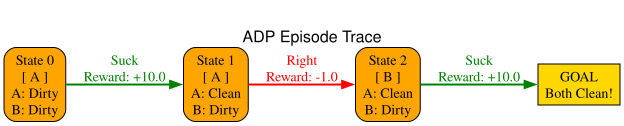

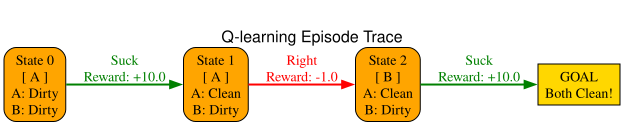

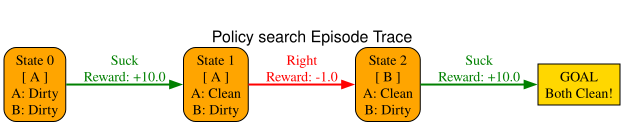

In [9]:
import graphviz
from IPython.display import display

def visualize_trace(name, trace):
    dot = graphviz.Digraph(comment=f'{name} Path Trace')
    dot.attr(rankdir='LR', size='10')
    
    # Add a title label inside the graph
    dot.attr(label=f'\n{name} Episode Trace', labelloc='t', fontsize='16', fontname='Helvetica')
    
    for idx, (state, action, reward, next_state) in enumerate(trace):
        pos, da, db = state
        next_pos, next_da, next_db = next_state
        
        # Format node labels to visually represent rooms
        node_label = f"State {idx}\n[ {pos} ]\nA: {'Dirty' if da else 'Clean'}\nB: {'Dirty' if db else 'Clean'}"
        next_node_label = f"State {idx+1}\n[ {next_pos} ]\nA: {'Dirty' if next_da else 'Clean'}\nB: {'Dirty' if next_db else 'Clean'}"
        
        # Style nodes depending on dirt status
        color = 'orange' if (da or db) else 'lightgreen'
        dot.node(f'S{idx}', node_label, shape='box', style='filled,rounded', fillcolor=color)
        
        next_color = 'lightgreen' if (not next_da and not next_db) else 'orange'
        dot.node(f'S{idx+1}', next_node_label, shape='box', style='filled,rounded', fillcolor=next_color)
        
        # Label transition with Action & Reward/Penalty
        edge_color = 'green' if reward > 0 else 'red'
        edge_label = f"{action}\nReward: {reward:+.1f}"
        dot.edge(f'S{idx}', f'S{idx+1}', label=edge_label, color=edge_color, fontcolor=edge_color, penwidth='2.0')

    # Mark the last state as the Goal if it is clean
    last_state = trace[-1][3]
    if is_terminal(last_state):
        dot.node(f'S{len(trace)}', style='filled,doublecircle', fillcolor='gold', label='GOAL\nBoth Clean!')
        
    display(dot)

# Generate visual traces for each of the RL methods
for name, policy in methods.items():
    if name == "Reference":
        continue
    _, trace = run_episode(policy, start_state=("A", 1, 1), seed=99, return_trace=True)
    visualize_trace(name, trace)

### Frame-by-Frame Visual Simulation

Let's build a dedicated visualizer that displays the simulation as distinct sequential frames. For each frame, we will draw the rooms (A and B) as large containers, showing their cleanliness status, and render the vacuum cleaner itself as a distinct circle inside its current room.


=== ADP Simulation Frames ===


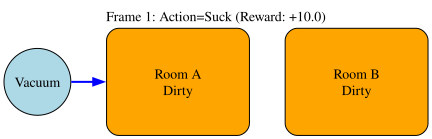

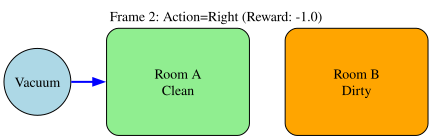

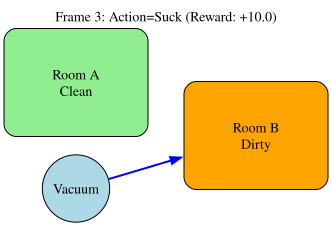


=== Q-learning Simulation Frames ===


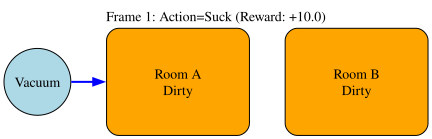

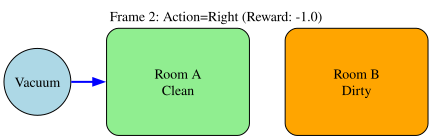

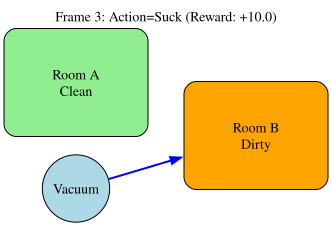


=== Policy search Simulation Frames ===


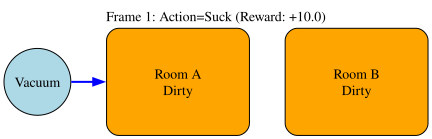

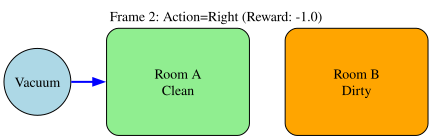

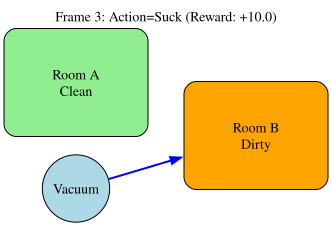

In [10]:
import graphviz
from IPython.display import display, HTML

def draw_frame(step_num, state, action, reward, next_state):
    pos, da, db = state
    next_pos, next_da, next_db = next_state
    
    dot = graphviz.Digraph(comment=f'Frame {step_num}')
    dot.attr(rankdir='LR', size='6')
    dot.attr(label=f'Frame {step_num}: Action={action} (Reward: {reward:+.1f})', labelloc='t', fontsize='14')
    
    # Style colors for Room statuses
    color_a = 'orange' if da else 'lightgreen'
    color_b = 'orange' if db else 'lightgreen'
    
    # Room Labels indicating clean/dirty status
    label_a = f"Room A\n{'Dirty' if da else 'Clean'}"
    label_b = f"Room B\n{'Dirty' if db else 'Clean'}"
    
    # Create nodes for the rooms
    dot.node('Room_A', label_a, shape='box', style='filled,rounded', fillcolor=color_a, width='2.0', height='1.5')
    dot.node('Room_B', label_b, shape='box', style='filled,rounded', fillcolor=color_b, width='2.0', height='1.5')
    
    # Create a simple invisible connection to keep layout side-by-side
    dot.edge('Room_A', 'Room_B', style='invis')
    
    # Draw the vacuum cleaner as a circle node and connect it to its current room container
    dot.node('Vacuum', 'Vacuum', shape='circle', style='filled', fillcolor='lightblue', width='0.8')
    if pos == 'A':
        dot.edge('Vacuum', 'Room_A', style='solid', color='blue', penwidth='2.0')
    else:
        dot.edge('Vacuum', 'Room_B', style='solid', color='blue', penwidth='2.0')
        
    return dot

def visualize_simulation_frames(name, trace):
    print(f"\n=== {name} Simulation Frames ===")
    for idx, (state, action, reward, next_state) in enumerate(trace):
        frame_dot = draw_frame(idx + 1, state, action, reward, next_state)
        display(frame_dot)

# Run the frame-by-frame visualizer for the three reinforcement learning methods
for name, policy in methods.items():
    if name == "Reference":
        continue
    _, trace = run_episode(policy, start_state=("A", 1, 1), seed=99, return_trace=True)
    visualize_simulation_frames(name, trace)

### Diverse Test Scenarios & Multi-State Generalization

Since the three methods have optimized policies that perform identically on the simple state (A, dirty, dirty), let's evaluate them across multiple different starting states to see how their trajectories diverge under different depths, slip circumstances, and start states.


STARTING SCENARIO: pos=B, A=dirty, B=dirty

=== ADP from ('B', 1, 1) Simulation Frames ===


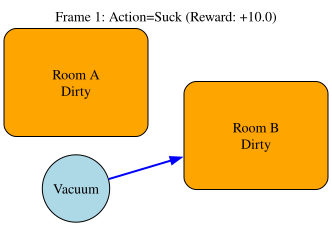

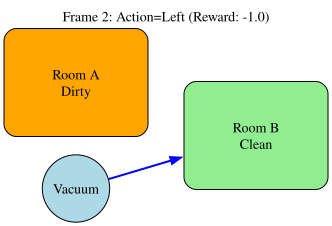

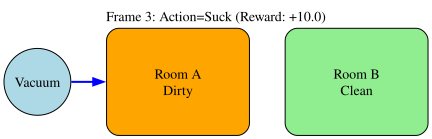


=== Q-learning from ('B', 1, 1) Simulation Frames ===


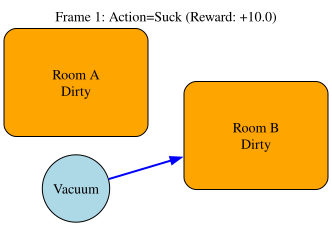

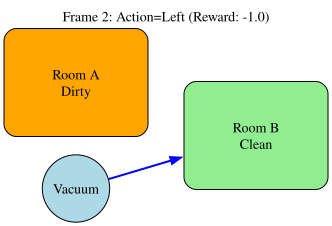

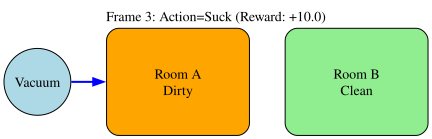


=== Policy search from ('B', 1, 1) Simulation Frames ===


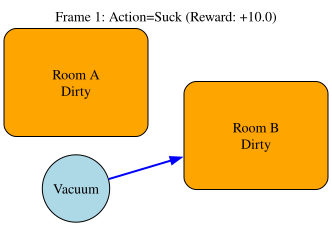

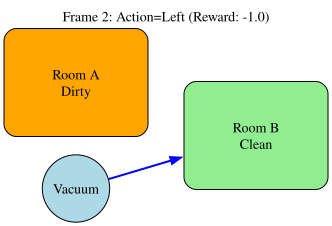

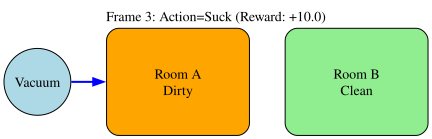


STARTING SCENARIO: pos=A, A=clean, B=dirty

=== ADP from ('A', 0, 1) Simulation Frames ===


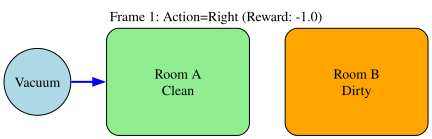

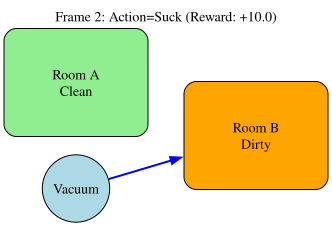


=== Q-learning from ('A', 0, 1) Simulation Frames ===


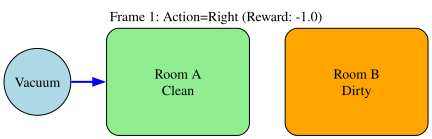

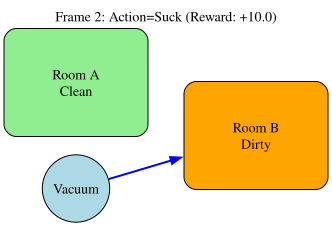


=== Policy search from ('A', 0, 1) Simulation Frames ===


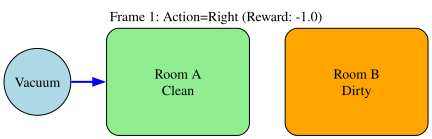

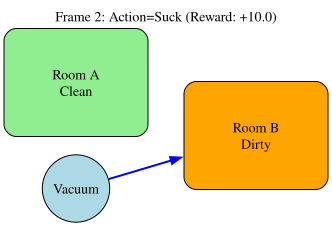


STARTING SCENARIO: pos=B, A=dirty, B=clean

=== ADP from ('B', 1, 0) Simulation Frames ===


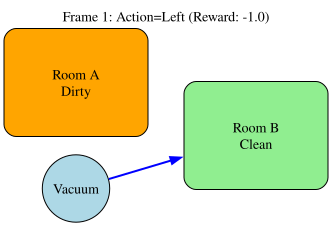

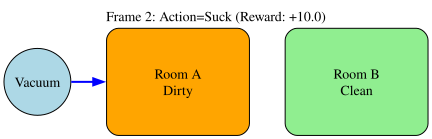


=== Q-learning from ('B', 1, 0) Simulation Frames ===


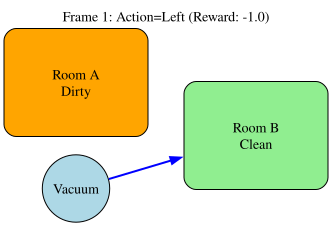

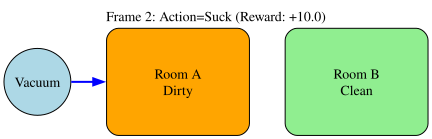


=== Policy search from ('B', 1, 0) Simulation Frames ===


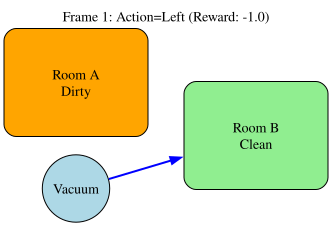

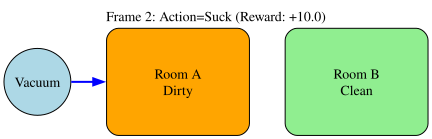

In [11]:
# Define a set of diverse starting states to test generalization
test_scenarios = [
    ("B", 1, 1), # Start at B with both rooms dirty
    ("A", 0, 1), # Start at A with only B dirty
    ("B", 1, 0), # Start at B with only A dirty
]

for start_state in test_scenarios:
    print(f"\n=========================================")
    print(f"STARTING SCENARIO: {state_label(start_state)}")
    print(f"=========================================")
    for name, policy in methods.items():
        if name == "Reference":
            continue
        # Run with max_steps=5 to show full depth behaviors
        _, trace = run_episode(policy, start_state=start_state, seed=42, max_steps=5, return_trace=True)
        visualize_simulation_frames(f"{name} from {start_state}", trace)

### Expanding the Environment: Multi-Room Levels

Redefine our vacuum world and frame-by-frame visual simulator to support rooms of arbitrary length across different configurations/levels:

- Level 1: Rooms `[A1, A2, A3]` where A3 is dirty.
- Level 2: Rooms `[B1, B2, B3, B4]` where B2 is dirty.
- Level 3: Rooms `[C1, C2]` where C1 is dirty.
- Level 4: Rooms `[D1, D2, D3]` where all rooms are clean.
- Level 5: Rooms `[E1, E2, E3, E4, E5]` where E1, E3, and E5 are dirty.

We will implement a generalized transition function where the actions are Left, Right, Suck, and NoOp, and the vacuum moves sequentially along the indexed rooms (e.g., from E2 to E1 with Left or E3 with Right).


SIMULATING: Level 1 (Rooms: ['A1', 'A2', 'A3'])


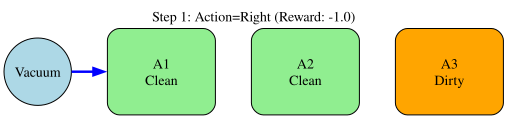

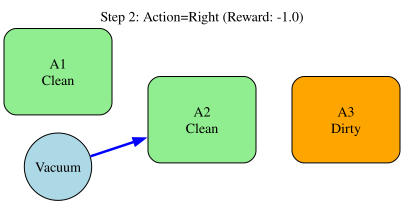

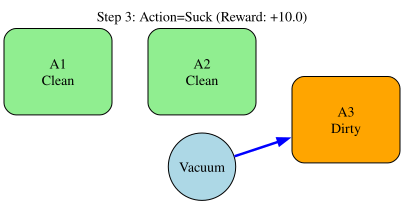

Goal reached: All rooms are clean!

SIMULATING: Level 2 (Rooms: ['B1', 'B2', 'B3', 'B4'])


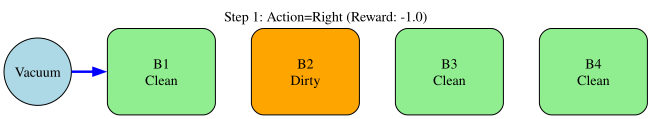

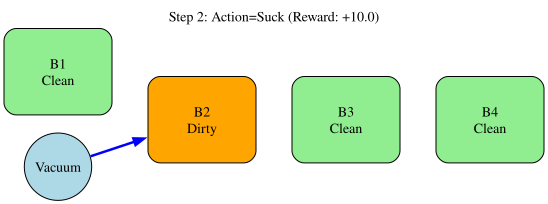

Goal reached: All rooms are clean!

SIMULATING: Level 3 (Rooms: ['C1', 'C2'])


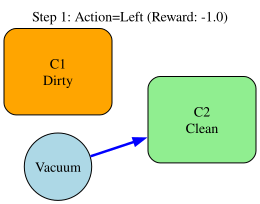

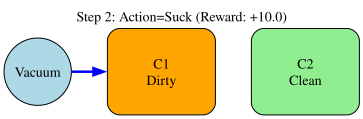

Goal reached: All rooms are clean!

SIMULATING: Level 4 (Rooms: ['D1', 'D2', 'D3'])
Goal reached: All rooms are clean!

SIMULATING: Level 5 (Rooms: ['E1', 'E2', 'E3', 'E4', 'E5'])


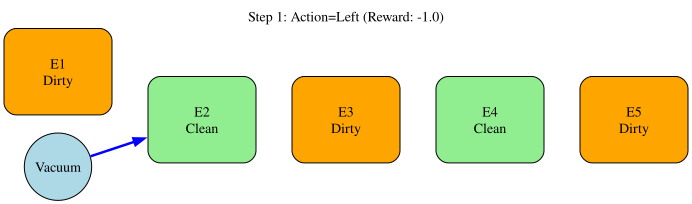

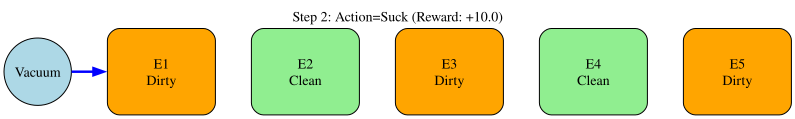

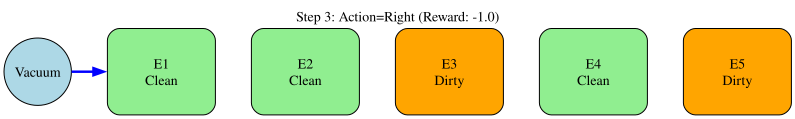

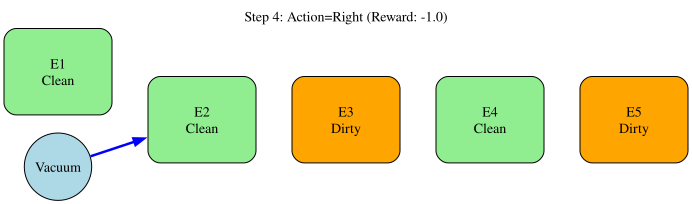

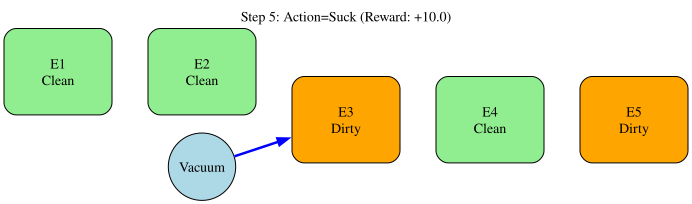

In [12]:
import graphviz
from IPython.display import display

# Configure the expanded multi-room levels
LEVELS = {
    "Level 1": {"rooms": ["A1", "A2", "A3"], "dirty": ["A3"], "start": "A1"},
    "Level 2": {"rooms": ["B1", "B2", "B3", "B4"], "dirty": ["B2"], "start": "B1"},
    "Level 3": {"rooms": ["C1", "C2"], "dirty": ["C1"], "start": "C2"},
    "Level 4": {"rooms": ["D1", "D2", "D3"], "dirty": [], "start": "D2"},
    "Level 5": {"rooms": ["E1", "E2", "E3", "E4", "E5"], "dirty": ["E1", "E3", "E5"], "start": "E2"}
}

def generalized_vacuum_step(state, action, rooms, slip_prob=0.10):
    # state is a tuple: (vacuum_position, tuple_of_dirty_status_0_or_1)
    pos, dirt_tuple = state
    pos_idx = rooms.index(pos)
    new_dirt = list(dirt_tuple)
    reward = -1.0
    
    if action == "Suck":
        if new_dirt[pos_idx] == 1:
            new_dirt[pos_idx] = 0
            reward = 10.0
        else:
            reward = -2.0
    elif action == "Left":
        if random.random() >= slip_prob:
            pos_idx = max(0, pos_idx - 1)
    elif action == "Right":
        if random.random() >= slip_prob:
            pos_idx = min(len(rooms) - 1, pos_idx + 1)
    elif action == "NoOp":
        reward = -1.0
        
    next_state = (rooms[pos_idx], tuple(new_dirt))
    return next_state, reward

def draw_generalized_frame(step_num, state, action, reward, next_state, rooms):
    pos, dirt_tuple = state
    dot = graphviz.Digraph(comment=f'Step {step_num}')
    dot.attr(rankdir='LR')
    dot.attr(label=f'Step {step_num}: Action={action} (Reward: {reward:+.1f})', labelloc='t', fontsize='14')
    
    # Render the rooms side-by-side
    for idx, r_name in enumerate(rooms):
        is_dirty = dirt_tuple[idx]
        color = 'orange' if is_dirty else 'lightgreen'
        label = f"{r_name}\n{'Dirty' if is_dirty else 'Clean'}"
        dot.node(r_name, label, shape='box', style='filled,rounded', fillcolor=color, width='1.5', height='1.2')
        
        # Keep ordering from left to right using invisible edges
        if idx > 0:
            dot.edge(rooms[idx - 1], r_name, style='invis')
            
    # Create the vacuum node and point it to the occupied room
    dot.node('Vacuum', 'Vacuum', shape='circle', style='filled', fillcolor='lightblue', width='0.8')
    dot.edge('Vacuum', pos, color='blue', penwidth='2.5')
    
    return dot

def run_and_visualize_level(level_name, level_config, steps=5):
    rooms = level_config["rooms"]
    initial_dirt = tuple(1 if r in level_config["dirty"] else 0 for r in rooms)
    state = (level_config["start"], initial_dirt)
    
    print(f"\n=========================================")
    print(f"SIMULATING: {level_name} (Rooms: {rooms})")
    print(f"=========================================")
    
    # Simple greedy rule to drive movement
    for step in range(1, steps + 1):
        pos, dirt_tuple = state
        pos_idx = rooms.index(pos)
        
        # Policy logic: Suck if dirty, otherwise move to nearest dirty room
        if dirt_tuple[pos_idx] == 1:
            action = "Suck"
        else:
            dirty_indices = [i for i, d in enumerate(dirt_tuple) if d == 1]
            if not dirty_indices:
                action = "NoOp"
            else:
                closest_dirty = min(dirty_indices, key=lambda idx: abs(idx - pos_idx))
                action = "Right" if closest_dirty > pos_idx else "Left"
                
        if all(d == 0 for d in dirt_tuple) and action == "NoOp":
            print(f"Goal reached: All rooms are clean!")
            break
            
        next_state, reward = generalized_vacuum_step(state, action, rooms, slip_prob=0.0)
        frame_dot = draw_generalized_frame(step, state, action, reward, next_state, rooms)
        display(frame_dot)
        state = next_state

# Execute simulation for all five levels
for lvl_name, lvl_cfg in LEVELS.items():
    run_and_visualize_level(lvl_name, lvl_cfg, steps=5)